04 Transport
笔记本： 04 transport20260403.1.ipynb
用了什么
库： geopandas、pandas、osmnx、networkx、osmium（pyosmium）、shapely、matplotlib、math（Haversine）等。
输入：
data_raw/guangdong.osm.pbf（广东 OSM，用于路网抽取）
data_raw/shenzhen_boundary.geojson（裁剪范围）
做了什么 / 算了什么
读深圳边界，合并多边形，画图展示范围。
方案： 用自定义 pyosmium handler 扫 PBF，按深圳边界筛选可通车道路类型（highway 从 motorway 到 service 等可行驶类别），保留道路属性（如 maxspeed、oneway、bridge、tunnel、lanes 等）。
用 Haversine 算每条道路的 length（米）；oneway 与反向路处理。
用 prepared 几何做深圳范围内裁剪（节点/边过滤）。
用 OSMnx 把点线转成 networkx 有向图，并调用 ox.routing.add_edge_speeds(..., fallback=30)（缺省限速按 30 km/h），得到 speed_kph、travel_time 等。
汇总：道路总长度（km）、平均 speed_kph 等；按 travel_time 找最快路径，并基于这条路径计算网络距离、直线距离、总时间和绕行比
（最快路径对应的“距离绕行比”，不是“最短距离路径的绕行比”）
写出文件
data_out/sz_drive.graphml
data_out/sz_drive_nodes.gpkg
data_out/sz_drive_edges.gpkg
典型输出信息： PBF 扫描/裁剪后的节点与边数量、图规模、总里程、平均车速、保存路径；可能有示例 OD 路线图或 “No route found”。

In [1]:
# !pip install osmnx geopandas networkx shapely matplotlib osmium

from pathlib import Path
import geopandas as gpd
import pandas as pd
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import osmium
from shapely.geometry import Point, LineString
from shapely.prepared import prep as shapely_prep
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings("ignore")

ox.settings.log_console = True
ox.settings.use_cache = True

RAW = Path("data_raw")
OUT = Path("data_out")
OUT.mkdir(exist_ok=True)
PBF = RAW / "guangdong.osm.pbf"

def haversine_m(lon1, lat1, lon2, lat2):
    """Haversine great-circle distance in metres."""
    R = 6_371_000
    la1, la2 = radians(lat1), radians(lat2)
    a = sin((la2 - la1) / 2) ** 2 + cos(la1) * cos(la2) * sin(radians(lon2 - lon1) / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

print(f"osmnx {ox.__version__}  |  pyosmium installed")
print(f"PBF exists: {PBF.exists()}")

/Users/shirly/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


osmnx 2.0.7  |  pyosmium installed
PBF exists: True


Boundary: MultiPolygon, bbox [113.75, 22.4, 114.62, 22.86]


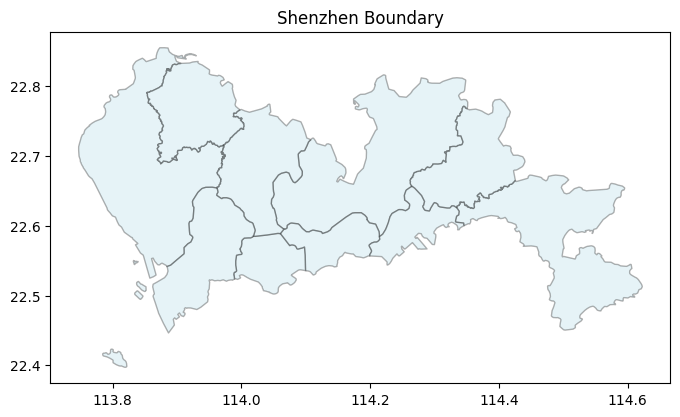

In [2]:
shenzhen = gpd.read_file(RAW / "shenzhen_boundary.geojson").to_crs(4326)
shenzhen_geom = (
    shenzhen.union_all() if hasattr(shenzhen, "union_all") else shenzhen.unary_union
)
print(f"Boundary: {shenzhen_geom.geom_type}, bbox {[round(x,2) for x in shenzhen_geom.bounds]}")
ax = shenzhen.plot(figsize=(8, 6), edgecolor="black", facecolor="lightblue", alpha=0.3)
ax.set_title("Shenzhen Boundary")
plt.show()

In [ ]:
# ============================================================
# 方案 : pyosmium 读取 Geofabrik PBF → osmnx 构建路由图
# PBF 文件: data_raw/guangdong.osm.pbf (已下载)
# ============================================================

DRIVE_TAGS = {
    "motorway", "motorway_link", "trunk", "trunk_link",
    "primary", "primary_link", "secondary", "secondary_link",
    "tertiary", "tertiary_link", "residential", "living_street",
    "unclassified", "service",
}

class DriveNetHandler(osmium.SimpleHandler):
    """单次扫描 PBF, 提取 bbox 内的可驾驶路网 (node coords + directed edges)."""

    def __init__(self, minx, miny, maxx, maxy):
        super().__init__()
        self.minx, self.miny, self.maxx, self.maxy = minx, miny, maxx, maxy
        self.node_xy = {}
        self.raw_edges = []

    def way(self, w):
        hw = w.tags.get("highway")
        if hw not in DRIVE_TAGS:
            return

        pts = [(n.ref, n.location.lon, n.location.lat)
               for n in w.nodes if n.location.valid()]
        if len(pts) < 2:
            return

        lons = [p[1] for p in pts]
        lats = [p[2] for p in pts]
        if max(lons) < self.minx or min(lons) > self.maxx:
            return
        if max(lats) < self.miny or min(lats) > self.maxy:
            return

        tags = dict(w.tags)
        for nid, lon, lat in pts:
            self.node_xy[nid] = (lon, lat)

        oneway_val = tags.get("oneway", "no")
        is_oneway = oneway_val in ("yes", "1", "true")
        is_reversed = oneway_val == "-1"
        if hw in ("motorway", "motorway_link") and oneway_val not in ("no", "0", "false"):
            is_oneway = True

        for i in range(len(pts) - 1):
            uid, ux, uy = pts[i]
            vid, vx, vy = pts[i + 1]
            seg_len = haversine_m(ux, uy, vx, vy)
            edata = dict(
                osmid=w.id, highway=hw, length=seg_len,
                name=tags.get("name", ""), maxspeed=tags.get("maxspeed"),
                bridge=tags.get("bridge"), tunnel=tags.get("tunnel"),
                lanes=tags.get("lanes"), surface=tags.get("surface"),
                oneway=is_oneway,
                geometry=LineString([(ux, uy), (vx, vy)]),
            )
            if is_reversed:
                edata["geometry"] = LineString([(vx, vy), (ux, uy)])
                self.raw_edges.append((vid, uid, edata))
            else:
                self.raw_edges.append((uid, vid, edata))
            if not is_oneway and not is_reversed:
                rev = edata.copy()
                rev["geometry"] = LineString([(vx, vy), (ux, uy)])
                self.raw_edges.append((vid, uid, rev))

# ── 1) 扫描 PBF ──
bbox = shenzhen_geom.bounds
print(f"Scanning {PBF.name}  bbox={[round(x,2) for x in bbox]} ...")
h = DriveNetHandler(*bbox)
h.apply_file(str(PBF), locations=True)
print(f"  bbox-filtered: {len(h.node_xy):,} nodes, {len(h.raw_edges):,} directed edges")

# ── 2) 精确裁剪到深圳多边形 ──
sz_prep = shapely_prep(shenzhen_geom)
inside = {nid for nid, (lon, lat) in h.node_xy.items()
          if sz_prep.contains(Point(lon, lat))}
edges_in = [(u, v, d) for u, v, d in h.raw_edges
            if u in inside or v in inside]
used = {u for u, v, _ in edges_in} | {v for _, v, _ in edges_in}
print(f"  clipped: {len(used):,} nodes, {len(edges_in):,} edges")

# ── 3) 构建 GeoDataFrames ──
nodes_gdf = gpd.GeoDataFrame(
    [{"osmid": nid, "x": xy[0], "y": xy[1], "geometry": Point(*xy)}
     for nid, xy in h.node_xy.items() if nid in used],
    crs=4326,
).set_index("osmid")

edf = pd.DataFrame([{"u": u, "v": v, **d} for u, v, d in edges_in])
edf["key"] = edf.groupby(["u", "v"]).cumcount()
edges_gdf = gpd.GeoDataFrame(edf, geometry="geometry", crs=4326
                             ).set_index(["u", "v", "key"])

# ── 4) 构建 OSMnx 兼容图 ──
try:
    G_raw = ox.convert.graph_from_gdfs(nodes_gdf, edges_gdf)
except AttributeError:
    G_raw = ox.utils_graph.graph_from_gdfs(nodes_gdf, edges_gdf)

print(f"\nGraph: {len(G_raw.nodes):,} nodes, {len(G_raw.edges):,} edges")
print(f"Road length: {edges_gdf['length'].sum() / 1000:,.0f} km")

del h  # release PBF scan memory

Scanning guangdong.osm.pbf  bbox=[113.75, 22.4, 114.62, 22.86] ...
  bbox-filtered: 649,713 nodes, 1,078,729 directed edges
  clipped: 409,106 nodes, 661,793 edges

Graph: 409,106 nodes, 661,793 edges
Road length: 23,293 km


In [4]:
G = ox.routing.add_edge_speeds(G_raw, fallback=30)   # km/h, 无 maxspeed 标签时用 30
G = ox.routing.add_edge_travel_times(G)               # 秒

try:
    nodes, edges = ox.convert.graph_to_gdfs(G)
except AttributeError:
    nodes, edges = ox.graph_to_gdfs(G)

print(f"Nodes : {len(nodes):,}")
print(f"Edges : {len(edges):,}")
print(f"Total : {edges['length'].sum() / 1000:,.0f} km")
print(f"Speed : {edges['speed_kph'].mean():.1f} km/h (avg)")

ox.save_graphml(G, filepath=str(OUT / "sz_drive.graphml"))
nodes.to_file(OUT / "sz_drive_nodes.gpkg", driver="GPKG")
edges.to_file(OUT / "sz_drive_edges.gpkg", driver="GPKG")
print("\nSaved -> data_out/sz_drive.graphml, sz_drive_nodes.gpkg, sz_drive_edges.gpkg")

Nodes : 409,106
Edges : 661,793
Total : 23,293 km
Speed : 32.0 km/h (avg)

Saved -> data_out/sz_drive.graphml, sz_drive_nodes.gpkg, sz_drive_edges.gpkg


Network   24.30 km
Straight  18.24 km
Time      19.0 min
Detour    1.332


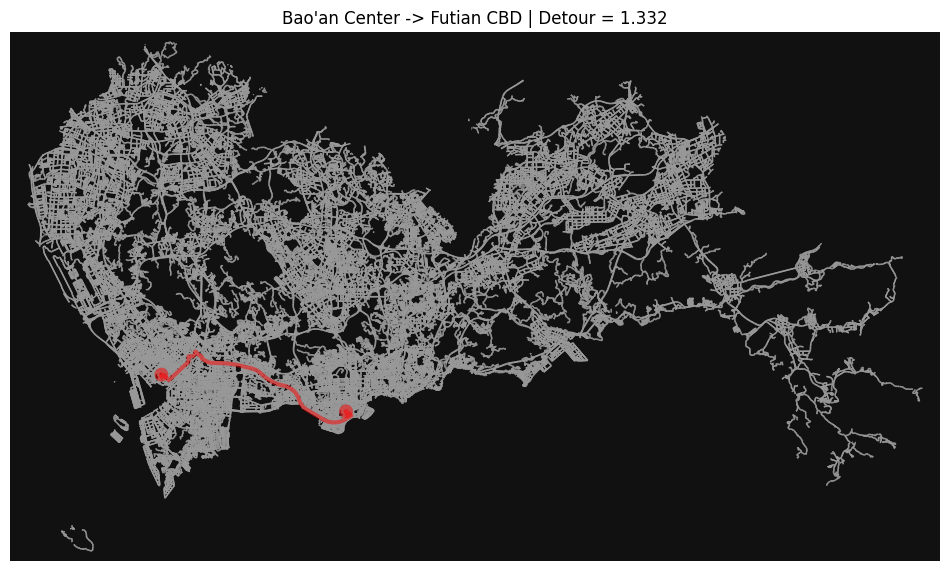

In [5]:
# ============================
#  Detour Ratio 绕行比分析
#  haversine_m 已在 Cell 0 定义
# ============================

def route_detour(G, olon, olat, dlon, dlat, weight="travel_time"):
    """
    计算 (olon,olat) -> (dlon,dlat) 的最短路径和绕行比。
    返回 dict(route, net_m, fly_m, tt_s, detour) 或 None。
    """
    o = ox.nearest_nodes(G, olon, olat)
    d = ox.nearest_nodes(G, dlon, dlat)
    path = ox.shortest_path(G, o, d, weight=weight)
    if path is None:
        return None
    gdf = ox.routing.route_to_gdf(G, path)
    net = gdf["length"].sum()
    tt  = gdf["travel_time"].sum()
    fly = haversine_m(olon, olat, dlon, dlat)
    return dict(route=path, net_m=net, fly_m=fly, tt_s=tt, detour=net / fly)

# ── 示例: 宝安中心 -> 福田 CBD ──
r = route_detour(G, 113.8838, 22.5550, 114.0579, 22.5227)
if r:
    print(f"Network   {r['net_m']/1e3:.2f} km")
    print(f"Straight  {r['fly_m']/1e3:.2f} km")
    print(f"Time      {r['tt_s']/60:.1f} min")
    print(f"Detour    {r['detour']:.3f}")
    fig, ax = ox.plot_graph_route(
        G, r["route"],
        route_color="red", route_linewidth=3,
        node_size=0, figsize=(12, 8),
        show=False, close=False,
    )
    ax.set_title(f"Bao'an Center -> Futian CBD | Detour = {r['detour']:.3f}")
    plt.show()
else:
    print("No route found")